# Artemis: Risk-Aware RL for a Lunar Mission

End-to-end notebook for the project proposal:

1. Build the MDP (env + true P, R).
2. Oracle: value iteration on the true MDP.
3. Four learning agents: Q-learning, UCB-Q, Model-based VI, PSRL/Thompson.
4. Multi-seed training, plots (success, return, regret).
5. Environment-variant experiments.
6. Learned-vs-oracle policy evaluation.

In [1]:
import sys, pathlib
root = pathlib.Path.cwd().resolve()
while root != root.parent and not (root / 'pyproject.toml').exists():
    root = root.parent
src = str((root / 'src').resolve())
if src not in sys.path:
    sys.path.insert(0, src)
print('root:', root)

root: D:\Users\Mateo\Personal\_RL\Artemis-risk-aware-RL


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from dataclasses import replace

from artemis.constants import (ACTION_SAFE, ACTION_RISKY, ACTION_FALLBACK,
    N_NON_TERMINAL, N_STATES, TERMINAL_SUCCESS, TERMINAL_FAILURE)
from artemis.environment import (MissionConfig, LunarMissionEnv,
    encode_state, decode_state, action_mask_int, get_transition_model_and_reward)
from artemis.planning import value_iteration, optimal_policy_for_mission, expected_return_from_state
from artemis.experiments import RunConfig, run_experiment, run_sweep, run_episode

plt.rcParams['figure.dpi'] = 110
GAMMA = 0.99  # high discount: makes the terminal +60 propagate strongly back 4 stages

# Hyperparameters.  The MDP has reward scale ±100 and oracle success ≈ 0.48.
#
# Key design decisions:
#   qlearning / ucb: moderate alpha + epsilon.  c_ucb=5 is ~5% of the reward range —
#     enough to distinguish unseen (s,a) pairs without swamping the signal.
#
#   model_based: epsilon=0.25 drives random exploration while VI refines the model.
#     pseudocount=0.01 so real counts dominate after ~10 visits per (s,a).
#
#   thompson: prior=1.0 = uninformative Dirichlet (Dir(1,…,1) = Uniform).
#     With a small prior the posterior concentrates on 1-2 successor states before
#     enough data has been collected, producing degenerate sampled MDPs.  With
#     prior=1.0 early samples are diverse enough to provide implicit exploration.
AGENT_KWARGS = {
    'qlearning':   {'alpha': 0.15, 'epsilon': 0.15},
    'ucb':         {'alpha': 0.15, 'c_ucb': 5.0},
    'model_based': {'epsilon': 0.25, 'vi_every': 5, 'pseudocount': 0.01},
    'thompson':    {'prior': 1.0, 'resample_each_episode': True},
}

## 1. Environment smoke test

State: (stage 1-4, fuel 0-2, hazard 0/1, fallback-available 0/1). 48 non-terminal states plus 2 absorbing terminals. Actions: safe, risky, fallback.

In [3]:
env = LunarMissionEnv(MissionConfig(), seed=0)
s, _ = env.reset()
print('start idx:', s, 'decoded:', decode_state(s))
print('legal actions:', action_mask_int(s))
for name, a in [('safe', ACTION_SAFE), ('risky', ACTION_RISKY), ('fallback', ACTION_FALLBACK)]:
    env.reset()
    sp, r, d, _, _ = env.step(a)
    print(f'{name:>8}: next={sp} r={r:+.1f} done={d}')

start idx: 8 decoded: (1, 2, 0, 0)
legal actions: [1 1 1]
    safe: next=16 r=+10.0 done=False
   risky: next=20 r=+10.0 done=False
fallback: next=17 r=+0.0 done=False


## 2. Oracle policy (VI on the true MDP)

Build the exact P(s'|s,a) and R-bar(s,a) from the spec, run vectorized value iteration. This gives V*, pi* (used for regret and as a reference policy).

In [4]:
cfg = MissionConfig()
P, R = get_transition_model_and_reward(cfg)
V_star, pi_star = value_iteration(P, R, gamma=GAMMA)
s0 = encode_state(1, cfg.start_fuel, 0, 0)
print(f'V*(s0) discounted (gamma={GAMMA}): {V_star[s0]:.3f}')

anames = {0: 'safe', 1: 'risky', 2: 'fallback'}
print('\nOracle policy, selected states:')
for stage in range(1, 5):
    for fuel in (2, 1):
        for h in (0, 1):
            s = encode_state(stage, fuel, h, 0)
            print(f'  (st={stage}, f={fuel}, h={h}, fb=0) -> {anames[int(pi_star[s])]:8s}  V*={V_star[s]:6.2f}')

V*(s0) discounted (gamma=0.99): -1.535

Oracle policy, selected states:
  (st=1, f=2, h=0, fb=0) -> risky     V*= -1.54
  (st=1, f=2, h=1, fb=0) -> risky     V*=-12.22
  (st=1, f=1, h=0, fb=0) -> risky     V*=-47.47
  (st=1, f=1, h=1, fb=0) -> risky     V*=-53.03
  (st=2, f=2, h=0, fb=0) -> risky     V*=  6.93
  (st=2, f=2, h=1, fb=0) -> risky     V*= -5.59
  (st=2, f=1, h=0, fb=0) -> risky     V*=-44.87
  (st=2, f=1, h=1, fb=0) -> risky     V*=-51.41
  (st=3, f=2, h=0, fb=0) -> risky     V*= 25.41
  (st=3, f=2, h=1, fb=0) -> risky     V*=  9.49
  (st=3, f=1, h=0, fb=0) -> risky     V*=-35.02
  (st=3, f=1, h=1, fb=0) -> risky     V*=-43.83
  (st=4, f=2, h=0, fb=0) -> safe      V*= 59.75
  (st=4, f=2, h=1, fb=0) -> safe      V*= 60.00
  (st=4, f=1, h=0, fb=0) -> risky     V*=-12.00
  (st=4, f=1, h=1, fb=0) -> risky     V*=-28.00


### V* heatmap — oracle value function

The heatmap below shows V*(s) for every (stage, fuel) combination under normal hazard status. The colour directly reveals *why* the oracle takes risky actions early: the value gap between fuel=2 and fuel=1 at stages 1–3 is enormous (≈ 50 points), so preserving fuel via the risky route's zero-fuel-cost safe branch is worth the failure risk. By stage 4 with fuel=2 the mission is nearly won and the oracle switches to safe to avoid catastrophic failure.

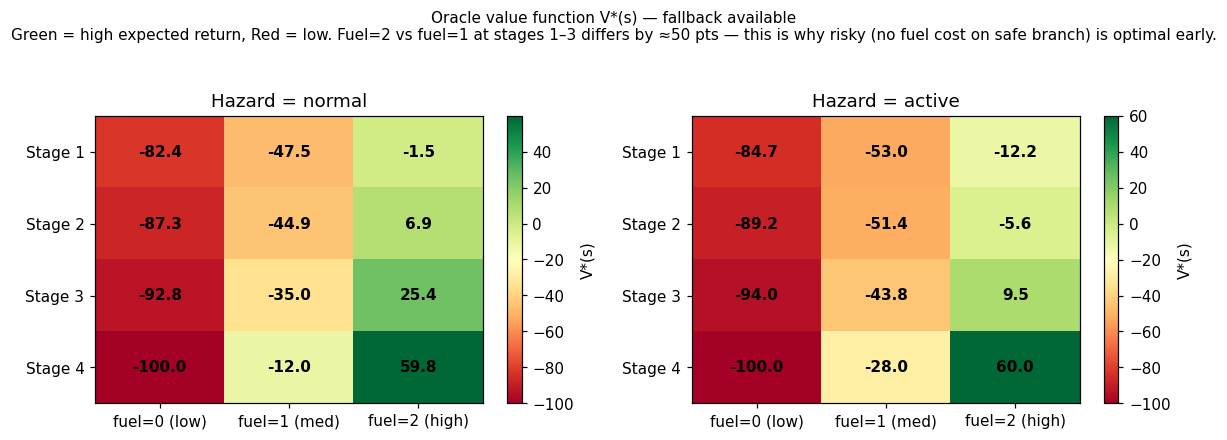

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

for ax_idx, (haz, htitle) in enumerate([(0, 'Hazard = normal'), (1, 'Hazard = active')]):
    grid = np.zeros((4, 3))
    for si, stage in enumerate(range(1, 5)):
        for fi, fuel in enumerate(range(3)):
            s = encode_state(stage, fuel, haz, 0)
            grid[si, fi] = V_star[s]

    im = axes[ax_idx].imshow(grid, cmap='RdYlGn', aspect='auto',
                             vmin=grid.min(), vmax=grid.max())
    for si in range(4):
        for fi in range(3):
            axes[ax_idx].text(fi, si, f'{grid[si, fi]:.1f}',
                              ha='center', va='center', fontsize=10, fontweight='bold',
                              color='black')
    axes[ax_idx].set_xticks([0, 1, 2])
    axes[ax_idx].set_xticklabels(['fuel=0 (low)', 'fuel=1 (med)', 'fuel=2 (high)'])
    axes[ax_idx].set_yticks(range(4))
    axes[ax_idx].set_yticklabels([f'Stage {s}' for s in range(1, 5)])
    axes[ax_idx].set_title(htitle, fontsize=12)
    fig.colorbar(im, ax=axes[ax_idx], label='V*(s)')

fig.suptitle('Oracle value function V*(s) — fallback available\n'
             'Green = high expected return, Red = low. '
             'Fuel=2 vs fuel=1 at stages 1–3 differs by ≈50 pts — '
             'this is why risky (no fuel cost on safe branch) is optimal early.',
             fontsize=10, y=1.04)
plt.tight_layout()
plt.show()

### Verification — transition probabilities, terminals, and oracle success rate

Proposal step 2 requires verifying P(s'|s,a) and the terminal conditions. Below we:

1. check every row of P sums to 1,
2. print the exact stage-dependent risky-route probabilities under **normal** and **hazard** statuses,
3. confirm terminals are absorbing with zero reward,
4. spot-check reward events (+10 stage progress, +60 success, −5 hazard entry, −10 fallback, −100 failure),
5. simulate the **oracle policy** 10 000 times to measure its achievable success rate (the upper bound any learner could reach).

In [6]:
from artemis.constants import RISKY_PROBS_NORMAL, RISKY_PROBS_HAZARD

row_sums = P.sum(axis=-1)
print(f'(1) P row-sum max error: {np.max(np.abs(row_sums - 1.0)):.2e} (should be ~0)')

print('\n(2) Risky-route probabilities under NORMAL hazard:')
for i, row in enumerate(RISKY_PROBS_NORMAL):
    print(f'  stage {i+1}: safe={row[0]:.2f}  hazard={row[1]:.2f}  fail={row[2]:.2f}  sum={row.sum():.2f}')
print('   Risky-route probabilities under HAZARD status:')
for i, row in enumerate(RISKY_PROBS_HAZARD):
    print(f'  stage {i+1}: safe={row[0]:.2f}  hazard={row[1]:.2f}  fail={row[2]:.2f}  sum={row.sum():.2f}')

print('\n(3) Terminals absorbing:')
for t, name in [(TERMINAL_SUCCESS, 'success'), (TERMINAL_FAILURE, 'failure')]:
    ok = all(P[t, a, t] == 1.0 and R[t, a] == 0.0 for a in range(3))
    print(f'  {name}: self-loop prob 1.0 and zero reward -> {ok}')

print('\n(4) Reward spot-checks:')
tenv = LunarMissionEnv(MissionConfig(), seed=1)
for _ in range(500):
    tenv.set_state(encode_state(4, 1, 0, 0))
    _, r, d, _, _ = tenv.step(ACTION_RISKY)
    if d and r > 0:
        print(f'  stage 4 -> success reward observed = {r:+.1f} (expected +60)')
        break

tenv.set_state(encode_state(1, 0, 0, 0))
_, r, d, _, _ = tenv.step(ACTION_SAFE)
print(f'  safe with fuel=0 -> terminates (done={d}) with reward {r:+.1f} (expected -100)')

tenv.set_state(encode_state(1, 2, 0, 1))
_, r, d, _, _ = tenv.step(ACTION_FALLBACK)
print(f'  fallback after used -> terminates (done={d}) with reward {r:+.1f} (expected -100)')

print('\n   Hazard-entry penalty check at (stage=1, fuel=2, normal), action=safe:')
s_test = encode_state(1, 2, 0, 0)
print(f'  R-bar[s, safe] = {R[s_test, ACTION_SAFE]:+.3f}  '
      f'(expected 10 + 0.05 * -5 = {10 + 0.05*-5:+.3f})')

print('\n(5) Oracle policy success rate (Monte-Carlo, 10 000 episodes):')
def simulate_policy(pi, n_episodes, seed=0):
    env = LunarMissionEnv(MissionConfig(), seed=seed)
    n_succ, rets = 0, []
    for _ in range(n_episodes):
        s, _ = env.reset()
        g = 0.0
        while s < N_NON_TERMINAL:
            s, r, d, _, _ = env.step(int(pi[s]))
            g += r
            if d:
                break
        if s == TERMINAL_SUCCESS:
            n_succ += 1
        rets.append(g)
    return n_succ / n_episodes, float(np.mean(rets))

oracle_succ, oracle_ret = simulate_policy(pi_star, n_episodes=10_000)
print(f'  oracle success rate = {oracle_succ:.3f}')
print(f'  oracle mean return  = {oracle_ret:+.2f}')
print(f'  => any learner is upper-bounded by ~{oracle_succ:.2f} success and ~{oracle_ret:+.1f} return.')

(1) P row-sum max error: 2.22e-16 (should be ~0)

(2) Risky-route probabilities under NORMAL hazard:
  stage 1: safe=0.75  hazard=0.20  fail=0.05  sum=1.00
  stage 2: safe=0.70  hazard=0.20  fail=0.10  sum=1.00
  stage 3: safe=0.65  hazard=0.20  fail=0.15  sum=1.00
  stage 4: safe=0.55  hazard=0.25  fail=0.20  sum=1.00
   Risky-route probabilities under HAZARD status:
  stage 1: safe=0.65  hazard=0.20  fail=0.15  sum=1.00
  stage 2: safe=0.60  hazard=0.20  fail=0.20  sum=1.00
  stage 3: safe=0.55  hazard=0.20  fail=0.25  sum=1.00
  stage 4: safe=0.45  hazard=0.25  fail=0.30  sum=1.00

(3) Terminals absorbing:
  success: self-loop prob 1.0 and zero reward -> True
  failure: self-loop prob 1.0 and zero reward -> True

(4) Reward spot-checks:
  stage 4 -> success reward observed = +60.0 (expected +60)
  safe with fuel=0 -> terminates (done=True) with reward -100.0 (expected -100)
  fallback after used -> terminates (done=True) with reward -100.0 (expected -100)

   Hazard-entry penalty ch

## 3. One run per agent (sanity check, 600 episodes)

In [7]:
AGENTS = ['qlearning', 'ucb', 'model_based', 'thompson']
single = {}
for a in AGENTS:
    rc = RunConfig(agent=a, n_episodes=600, gamma=GAMMA, seed=0,
                   agent_kwargs=AGENT_KWARGS[a])
    single[a] = run_experiment(rc)
    res = single[a]
    print(f"{a:12s}  final_success={res['final_success_rate_last_window']:.3f}  "
          f"final_return={res['final_mean_return_last_window']:.2f}  "
          f"ep_to_0.8={res['episodes_to_0p8_rolling_success']}")

qlearning     final_success=0.333  final_return=-29.33  ep_to_0.8=-1
ucb           final_success=0.417  final_return=-7.33  ep_to_0.8=-1
model_based   final_success=0.433  final_return=-8.08  ep_to_0.8=-1
thompson      final_success=0.417  final_return=-9.33  ep_to_0.8=-1


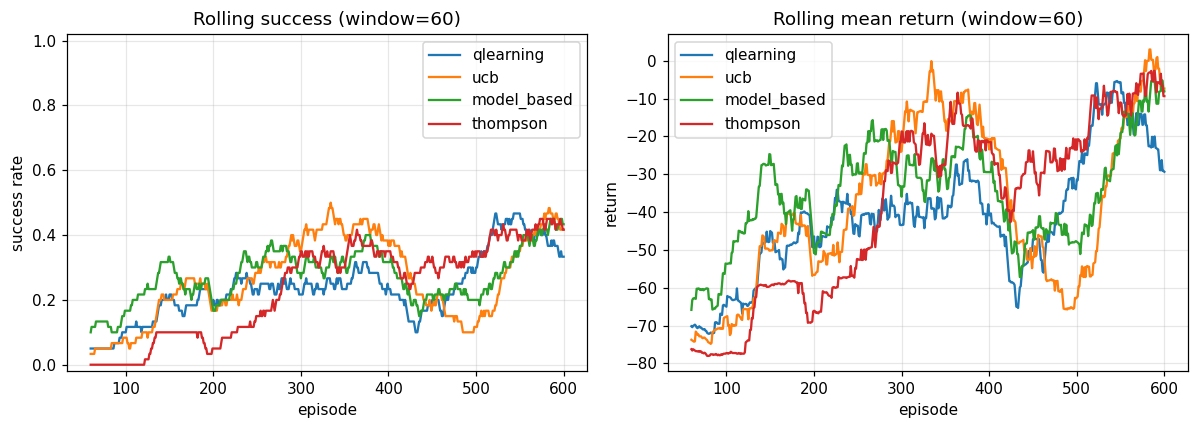

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for a in AGENTS:
    w = single[a]['moving_avg_window']
    sm = np.asarray(single[a]['success_rate_moving'])
    rm = np.asarray(single[a]['return_moving_mean'])
    x = np.arange(sm.size) + w
    axes[0].plot(x, sm, label=a)
    axes[1].plot(x, rm, label=a)
axes[0].set_title(f'Rolling success (window={w})'); axes[0].set_ylim(-0.02, 1.02)
axes[0].set_xlabel('episode'); axes[0].set_ylabel('success rate'); axes[0].grid(alpha=0.3); axes[0].legend()
axes[1].set_title(f'Rolling mean return (window={w})')
axes[1].set_xlabel('episode'); axes[1].set_ylabel('return'); axes[1].grid(alpha=0.3); axes[1].legend()
plt.tight_layout(); plt.show()

### Episode trajectory trace — one full episode per agent

Rather than summary statistics, this section shows exactly what happens inside a single episode for each agent after training: the action chosen at each stage, the outcome, and the resulting fuel and hazard state. This bridges the gap between abstract numbers and the actual mission dynamics the proposal describes.

In [9]:
from artemis.agents.q_learning import QLearningAgent
from artemis.agents.ucb import UCQAgent
from artemis.agents.model_based import ModelBasedVIAgent
from artemis.agents.thompson import ThompsonSamplingMDPAgent

STAGE_NAMES = {1: 'Launch', 2: 'Earth dep.', 3: 'Midcourse', 4: 'Lunar app.', 5: 'Complete'}
ACTION_NAMES = {0: 'safe    ', 1: 'risky   ', 2: 'fallback'}
ACTION_COLORS = {0: '\033[34m', 1: '\033[33m', 2: '\033[35m'}  # blue / yellow / magenta
RESET = '\033[0m'

_TRACE_N_TRAIN = 2000  # episodes to train before collecting the trace

def run_traced_episode(agent, seed=7, n_train=_TRACE_N_TRAIN):
    """Train agent for n_train episodes, then run one greedy episode and return the trace."""
    env = LunarMissionEnv(MissionConfig(), seed=seed)
    for _ in range(n_train):
        run_episode(env, agent)
    # one greedy episode — zero out epsilon / force greedy
    env2 = LunarMissionEnv(MissionConfig(), seed=seed + 100)
    trace = []
    s, _ = env2.reset()
    ep_return = 0.0
    while s < N_NON_TERMINAL:
        stage, fuel, haz, fb = decode_state(s)
        mask = action_mask_int(s)
        a = agent.act(s, mask)
        s_next, r, done, _, _ = env2.step(a)
        ep_return += r
        outcome = 'success' if s_next == TERMINAL_SUCCESS else ('failure' if s_next == TERMINAL_FAILURE else 'advance')
        trace.append({'stage': stage, 'stage_name': STAGE_NAMES[stage],
                      'fuel_before': fuel, 'hazard': bool(haz), 'fb_avail': not bool(fb),
                      'action': a, 'reward': r, 'outcome': outcome})
        s = s_next
        if done:
            break
    return trace, ep_return, s == TERMINAL_SUCCESS

def make_agent(kind, seed):
    kw = dict(AGENT_KWARGS[kind])
    if kind == 'qlearning':
        return QLearningAgent(gamma=GAMMA, seed=seed, alpha=kw.get('alpha', 0.15), epsilon=kw.get('epsilon', 0.15))
    if kind == 'ucb':
        return UCQAgent(gamma=GAMMA, seed=seed, alpha=kw.get('alpha', 0.15), c_ucb=kw.get('c_ucb', 5.0))
    if kind == 'model_based':
        return ModelBasedVIAgent(gamma=GAMMA, seed=seed, epsilon=kw.get('epsilon', 0.25),
                                 vi_every=kw.get('vi_every', 5), pseudocount=kw.get('pseudocount', 0.01))
    return ThompsonSamplingMDPAgent(gamma=GAMMA, seed=seed, prior=kw.get('prior', 1.0))

print('Training agents and collecting episode traces ...\n')
traces = {}
for kind in AGENTS:
    ag = make_agent(kind, seed=42)
    traces[kind] = run_traced_episode(ag, seed=7, n_train=_TRACE_N_TRAIN)

# ── pretty-print table ────────────────────────────────────────────────────────
col_w = 14
header = f"{'Stage':<14}{'Fuel':>6}{'Hazard':>8}{'Fallback':>10}  {'Action':<10}{'Reward':>8}  {'Outcome'}"

for kind, (trace, ep_ret, success) in traces.items():
    result_str = '✓ SUCCESS' if success else '✗ FAILURE'
    print(f'{'─'*70}')
    print(f'  Agent: {kind.upper():<14}  Episode return: {ep_ret:+.1f}   {result_str}')
    print(f'{'─'*70}')
    print(f"  {header}")
    print(f"  {'─'*66}")
    for step in trace:
        aname = ACTION_NAMES[step['action']]
        haz_str = '⚠ yes' if step['hazard'] else 'no'
        fb_str = 'yes' if step['fb_avail'] else 'used'
        out_str = {'advance': '→ next stage', 'success': '★ mission success', 'failure': '✗ failure'}[step['outcome']]
        print(f"  {step['stage_name']:<14}{step['fuel_before']:>4}     {haz_str:>6}   {fb_str:>6}    {aname}  {step['reward']:>+6.0f}    {out_str}")
    print()

Training agents and collecting episode traces ...

──────────────────────────────────────────────────────────────────────
  Agent: QLEARNING       Episode return: +90.0   ✓ SUCCESS
──────────────────────────────────────────────────────────────────────
  Stage           Fuel  Hazard  Fallback  Action      Reward  Outcome
  ──────────────────────────────────────────────────────────────────
  Launch           2         no      yes    risky        +10    → next stage
  Earth dep.       2         no      yes    risky        +10    → next stage
  Midcourse        2         no      yes    risky        +10    → next stage
  Lunar app.       2         no      yes    safe         +60    ★ mission success

──────────────────────────────────────────────────────────────────────
  Agent: UCB             Episode return: -80.0   ✗ FAILURE
──────────────────────────────────────────────────────────────────────
  Stage           Fuel  Hazard  Fallback  Action      Reward  Outcome
  ──────────────────────

C:\Users\MATEO\AppData\Local\Temp\ipykernel_32516\728086754.py:47: UserWarning: Glyph 9981 (\N{FUEL PUMP}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.06, 1, 1])
C:\Users\MATEO\anaconda3\envs\rl\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9981 (\N{FUEL PUMP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


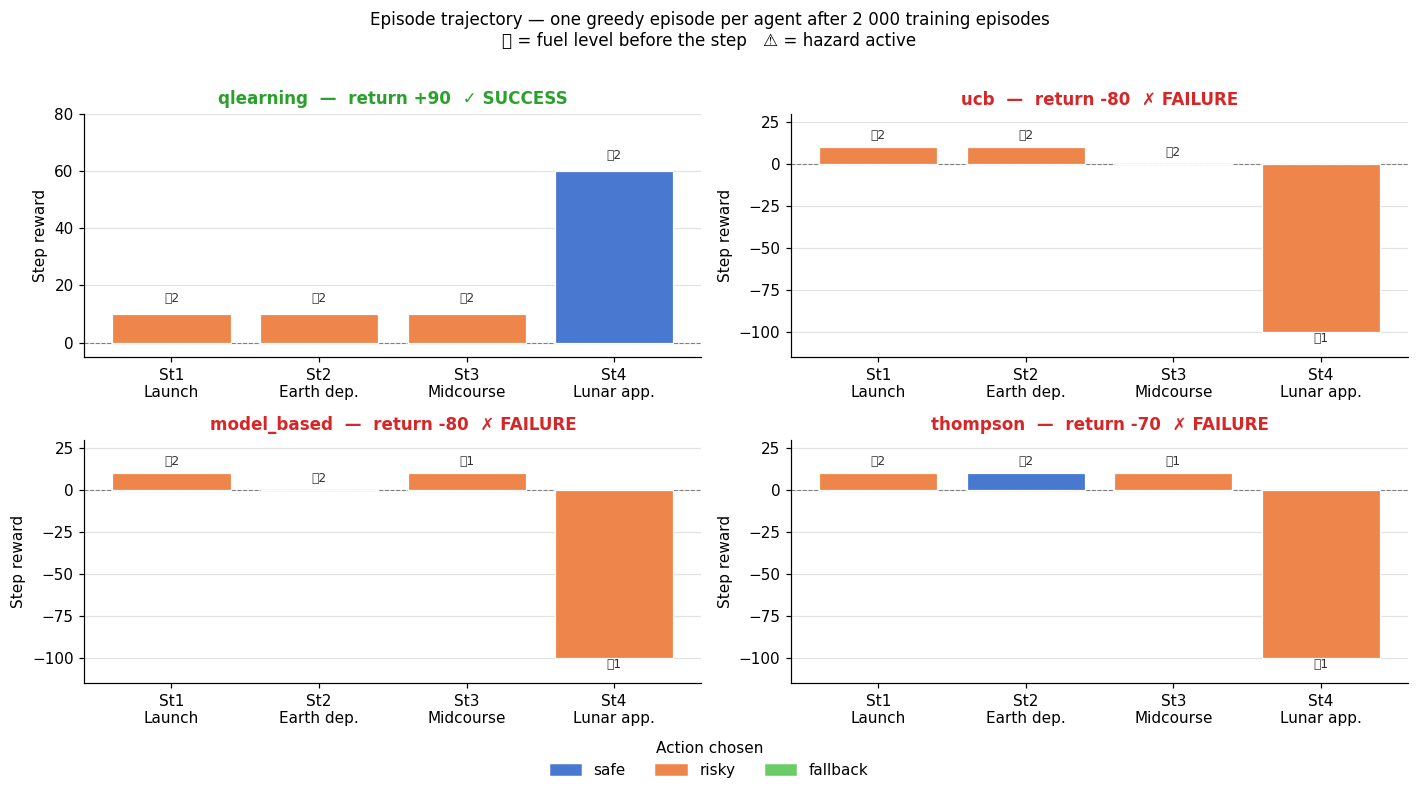

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
axes = axes.flatten()

act_palette = {0: '#4878d0', 1: '#ee854a', 2: '#6acc65'}  # safe=blue, risky=orange, fallback=green
act_labels  = {0: 'safe', 1: 'risky', 2: 'fallback'}

for ax, kind in zip(axes, AGENTS):
    trace, ep_ret, success = traces[kind]
    stages     = [f"St{s['stage']}\n{s['stage_name']}" for s in trace]
    rewards    = [s['reward'] for s in trace]
    fuels      = [s['fuel_before'] for s in trace]
    actions    = [s['action']  for s in trace]
    colors     = [act_palette[a] for a in actions]

    # bar = reward per step, coloured by action
    bars = ax.bar(stages, rewards, color=colors, edgecolor='white', linewidth=0.8, zorder=3)
    ax.axhline(0, color='gray', linewidth=0.7, linestyle='--', zorder=2)

    # fuel level annotation above each bar
    for i, (bar, f) in enumerate(zip(bars, fuels)):
        y = rewards[i]
        offset = 3 if y >= 0 else -8
        ax.text(i, y + offset, f'⛽{f}', ha='center', va='bottom', fontsize=8, color='#333333')

    # hazard warning on the bar itself
    for i, step in enumerate(trace):
        if step['hazard']:
            ax.text(i, rewards[i] / 2, '⚠', ha='center', va='center', fontsize=10)

    result_color = '#2ca02c' if success else '#d62728'
    result_label = '✓ SUCCESS' if success else '✗ FAILURE'
    ax.set_title(f'{kind}  —  return {ep_ret:+.0f}  {result_label}',
                 color=result_color, fontweight='bold', fontsize=11)
    ax.set_ylabel('Step reward')
    ax.set_ylim(min(rewards) - 15, max(rewards) + 20)
    ax.grid(axis='y', alpha=0.35, zorder=0)
    ax.spines[['top', 'right']].set_visible(False)

# shared legend
from matplotlib.patches import Patch
legend_handles = [Patch(color=act_palette[a], label=act_labels[a]) for a in [0, 1, 2]]
fig.legend(handles=legend_handles, loc='lower center', ncol=3, frameon=False,
           fontsize=10, title='Action chosen', title_fontsize=10)

fig.suptitle('Episode trajectory — one greedy episode per agent after 2 000 training episodes\n'
             '⛽ = fuel level before the step   ⚠ = hazard active', fontsize=11, y=1.01)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

## 4. Multi-seed sweep (default mission)

5 seeds x 4 agents x 1500 episodes. Shaded band = +/- 1 std across seeds.

In [11]:
N_EP = 2000
SEEDS = [0, 1, 2, 3, 4]
base_runs = run_sweep(AGENTS, SEEDS, n_episodes=N_EP, gamma=GAMMA,
                     mission=MissionConfig(), agent_kwargs=AGENT_KWARGS, save=False)
print(f'ran {len(base_runs)} runs')

ran 20 runs


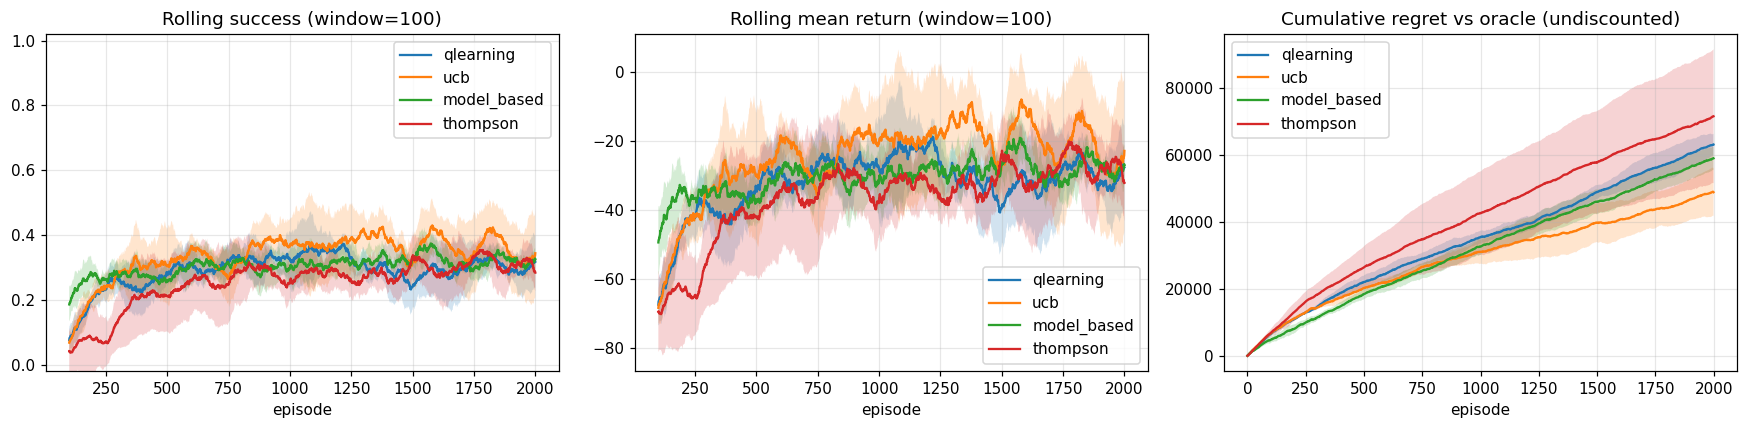

In [12]:
def curves_by_agent(runs, key):
    out = {}
    for r in runs:
        out.setdefault(r['method'], []).append(np.asarray(r[key], dtype=np.float64))
    for m, xs in out.items():
        L = min(x.size for x in xs)
        out[m] = np.stack([x[:L] for x in xs], axis=0)
    return out

def plot_band(ax, runs, key, x_off=0, title=''):
    data = curves_by_agent(runs, key)
    for m, arr in data.items():
        mu, sd = arr.mean(0), arr.std(0)
        x = np.arange(mu.size) + x_off
        ax.plot(x, mu, label=m)
        ax.fill_between(x, mu - sd, mu + sd, alpha=0.2)
    ax.set_title(title); ax.set_xlabel('episode'); ax.grid(alpha=0.3); ax.legend()

win = base_runs[0]['moving_avg_window']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_band(axes[0], base_runs, 'success_rate_moving', x_off=win, title=f'Rolling success (window={win})')
axes[0].set_ylim(-0.02, 1.02)
plot_band(axes[1], base_runs, 'return_moving_mean', x_off=win, title=f'Rolling mean return (window={win})')
plot_band(axes[2], base_runs, 'cumulative_regret', title='Cumulative regret vs oracle (undiscounted)')
plt.tight_layout(); plt.show()

In [13]:
rows = []
for r in base_runs:
    rows.append({'agent': r['method'], 'seed': r['seed'],
        'final_success': r['final_success_rate_last_window'],
        'final_return': r['final_mean_return_last_window'],
        'hazard_rate': r['mean_hazard_rate'],
        'ep_to_0p8': r['episodes_to_0p8_rolling_success'],
        'total_regret': r['cumulative_regret'][-1]})
df = pd.DataFrame(rows)
df.groupby('agent').agg(['mean', 'std']).round(3)

seed        final_success        final_return         hazard_rate  \
            mean    std          mean    std         mean     std        mean   
agent                                                                           
model_based  2.0  1.581         0.326  0.034       -27.08   6.129       0.127   
qlearning    2.0  1.581         0.318  0.089       -27.74  13.418       0.122   
thompson     2.0  1.581         0.284  0.063       -32.24  12.278       0.106   
ucb          2.0  1.581         0.344  0.149       -22.94  25.830       0.127   

                   ep_to_0p8      total_regret             
               std      mean  std         mean        std  
agent                                                      
model_based  0.010      -1.0  0.0    58935.375   3832.105  
qlearning    0.004      -1.0  0.0    63060.375   3604.356  
thompson     0.014      -1.0  0.0    71485.375  22239.051  
ucb          0.003      -1.0  0.0    48853.375   8001.624

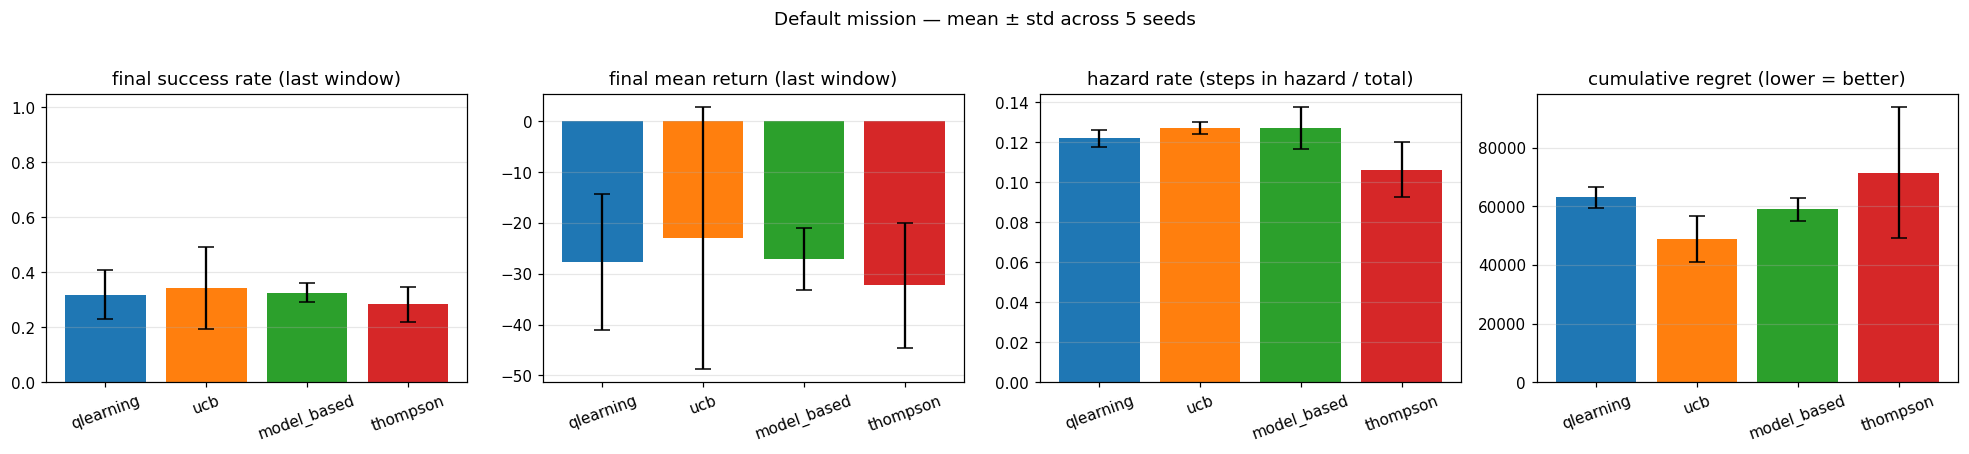

In [14]:
agg = df.groupby('agent').agg(
    success_mean=('final_success', 'mean'), success_std=('final_success', 'std'),
    return_mean=('final_return', 'mean'), return_std=('final_return', 'std'),
    hazard_mean=('hazard_rate', 'mean'), hazard_std=('hazard_rate', 'std'),
    regret_mean=('total_regret', 'mean'), regret_std=('total_regret', 'std'),
).reindex(AGENTS)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
panels = [
    ('success_mean', 'success_std', 'final success rate (last window)',   axes[0]),
    ('return_mean',  'return_std',  'final mean return (last window)',     axes[1]),
    ('hazard_mean',  'hazard_std',  'hazard rate (steps in hazard / total)', axes[2]),
    ('regret_mean',  'regret_std',  'cumulative regret (lower = better)',  axes[3]),
]
x = np.arange(len(AGENTS))
for mean_col, std_col, title, ax in panels:
    ax.bar(x, agg[mean_col].values, yerr=agg[std_col].values, capsize=5,
           color=['#1f77b4','#ff7f0e','#2ca02c','#d62728'])
    ax.set_xticks(x); ax.set_xticklabels(AGENTS, rotation=20)
    ax.set_title(title); ax.grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, 1.05)
plt.suptitle(f'Default mission — mean ± std across {len(SEEDS)} seeds', y=1.02)
plt.tight_layout(); plt.show()

## 5. Environment variants

- `risky_x2`: double risky-route failure probability (renormalized)
- `harsh_hazard`: hazard penalty -15 instead of -5
- `weak_fallback`: fallback recovery prob 0.5 instead of 0.9
- `low_fuel`: start fuel = 1 instead of 2

In [15]:
VARIANTS = {
    'default':       MissionConfig(),
    'risky_x2':      MissionConfig(risky_failure_scale=2.0),
    'harsh_hazard':  MissionConfig(hazard_penalty=-15.0),
    'weak_fallback': MissionConfig(fallback_recovery_prob=0.5),
    'low_fuel':      MissionConfig(start_fuel=1),
}
VARIANT_SEEDS = [0, 1, 2]
VARIANT_N_EP = 1000
variant_runs = {}
for name, vcfg in VARIANTS.items():
    print(f'== {name} ==')
    variant_runs[name] = run_sweep(AGENTS, VARIANT_SEEDS, n_episodes=VARIANT_N_EP, gamma=GAMMA,
                                   mission=vcfg, agent_kwargs=AGENT_KWARGS, save=False)

== default ==
== risky_x2 ==
== harsh_hazard ==
== weak_fallback ==
== low_fuel ==


In [16]:
rows = []
for vname, runs in variant_runs.items():
    for r in runs:
        rows.append({'variant': vname, 'agent': r['method'], 'seed': r['seed'],
            'final_success': r['final_success_rate_last_window'],
            'final_return': r['final_mean_return_last_window'],
            'hazard_rate': r['mean_hazard_rate'],
            'total_regret': r['cumulative_regret'][-1]})
vdf = pd.DataFrame(rows)
vsum = vdf.groupby(['variant', 'agent'])[['final_success','final_return','hazard_rate','total_regret']].mean().round(3)
vsum

final_success  final_return  hazard_rate  \
variant       agent                                                   
default       model_based          0.303       -31.500        0.121   
              qlearning            0.310       -31.617        0.111   
              thompson             0.277       -32.600        0.102   
              ucb                  0.340       -25.883        0.113   
harsh_hazard  model_based          0.307       -35.100        0.120   
              qlearning            0.330       -29.783        0.112   
              thompson             0.273       -36.700        0.086   
              ucb                  0.340       -29.117        0.112   
low_fuel      model_based          0.040       -73.183        0.067   
              qlearning            0.133       -58.283        0.106   
              thompson             0.000       -78.467        0.051   
              ucb                  0.193       -47.800        0.117   
risky_x2      model_based          0.173       -53.833        0.096   
              qlearning            0.217       -47.533        0.100   
              thompson             0.003       -77.400        0.053   
              ucb                  0.113       -60.883        0.096   
weak_fallback model_based          0.270       -36.750        0.121   
              qlearning            0.337       -27.100        0.113   
              thompson             0.267       -33.700        0.108   
              ucb                  0.373       -22.133        0.121   

                           total_regret  
variant       agent                      
default       model_based     31857.854  
              qlearning       35689.521  
              thompson        35991.188  
              ucb             32666.188  
harsh_hazard  model_based     30545.563  
              qlearning       35580.563  
              thompson        44812.229  
              ucb             33098.896  
low_fuel      model_based     27370.833  
              qlearning       14017.500  
              thompson        30304.167  
              ucb              7637.500  
risky_x2      model_based     20524.408  
              qlearning       21952.741  
              thompson        42531.074  
              ucb             24757.741  
weak_fallback model_based     33629.521  
              qlearning       37247.854  
              thompson        39524.521  
              ucb             29479.521

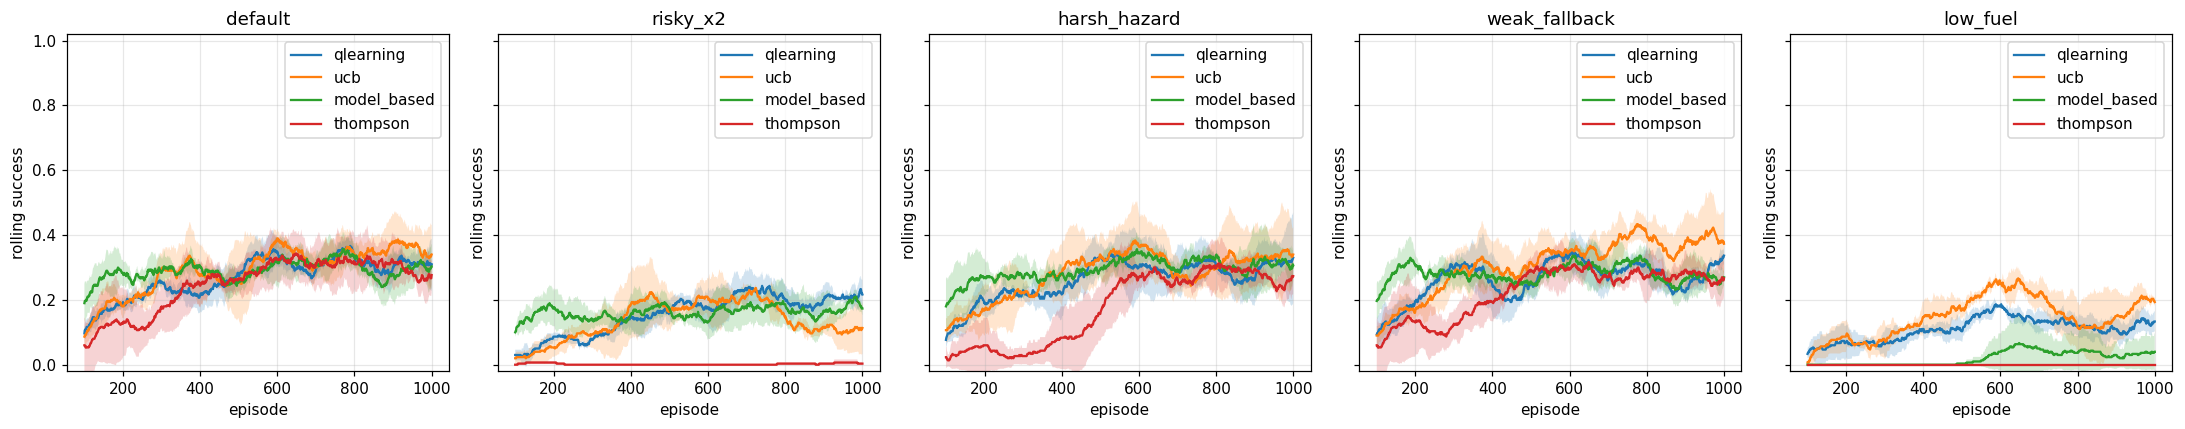

In [17]:
fig, axes = plt.subplots(1, len(VARIANTS), figsize=(4*len(VARIANTS), 4), sharey=True)
for ax, (vname, runs) in zip(axes, variant_runs.items()):
    plot_band(ax, runs, 'success_rate_moving', x_off=runs[0]['moving_avg_window'], title=vname)
    ax.set_ylim(-0.02, 1.02); ax.set_ylabel('rolling success')
plt.tight_layout(); plt.show()

## 6. Learned vs. oracle policy (evaluated on true MDP)

For each agent, take the greedy policy induced by its final Q and compute its expected discounted return from s0 on the **true** P, R. Compare to V*(s0).

In [18]:
from artemis.agents.q_learning import QLearningAgent
from artemis.agents.ucb import UCQAgent
from artemis.agents.model_based import ModelBasedVIAgent
from artemis.agents.thompson import ThompsonSamplingMDPAgent

def greedy_pi_from_q(Q):
    pi = np.zeros(N_STATES, dtype=np.int64)
    for s in range(N_STATES):
        m = action_mask_int(s)
        if (m == 1).any():
            q = Q[s].copy(); q[m == 0] = -np.inf
            pi[s] = int(q.argmax())
    return pi

def train_and_get_Q(kind, seed, n_ep=N_EP):
    env = LunarMissionEnv(MissionConfig(), seed=seed)
    kw = dict(AGENT_KWARGS[kind])
    if kind == 'qlearning':
        ag = QLearningAgent(gamma=GAMMA, seed=seed,
                            alpha=kw.get('alpha', 0.15), epsilon=kw.get('epsilon', 0.15))
    elif kind == 'ucb':
        ag = UCQAgent(gamma=GAMMA, seed=seed,
                      alpha=kw.get('alpha', 0.15), c_ucb=kw.get('c_ucb', 5.0))
    elif kind == 'model_based':
        ag = ModelBasedVIAgent(gamma=GAMMA, seed=seed,
                               epsilon=kw.get('epsilon', 0.25),
                               vi_every=kw.get('vi_every', 5),
                               pseudocount=kw.get('pseudocount', 0.01))
    else:
        ag = ThompsonSamplingMDPAgent(gamma=GAMMA, seed=seed,
                                      prior=kw.get('prior', 1.0))
    for _ in range(n_ep):
        run_episode(env, ag)
    return ag.Q if hasattr(ag, 'Q') else ag._q

V_oracle = float(V_star[s0])
print(f'V*(s0) = {V_oracle:.3f}')
for kind in AGENTS:
    Q = train_and_get_Q(kind, seed=0, n_ep=N_EP)
    pi = greedy_pi_from_q(Q)
    g = expected_return_from_state(P, R, pi, s0, gamma=GAMMA)
    print(f'{kind:12s}: V^pi(s0)={g:7.3f}  gap to V* = {V_oracle - g:+.3f}')

V*(s0) = -1.535
qlearning   : V^pi(s0)=-16.111  gap to V* = +14.576
ucb         : V^pi(s0)=-25.507  gap to V* = +23.971
model_based : V^pi(s0)= -1.535  gap to V* = +0.000
thompson    : V^pi(s0)=-16.111  gap to V* = +14.576


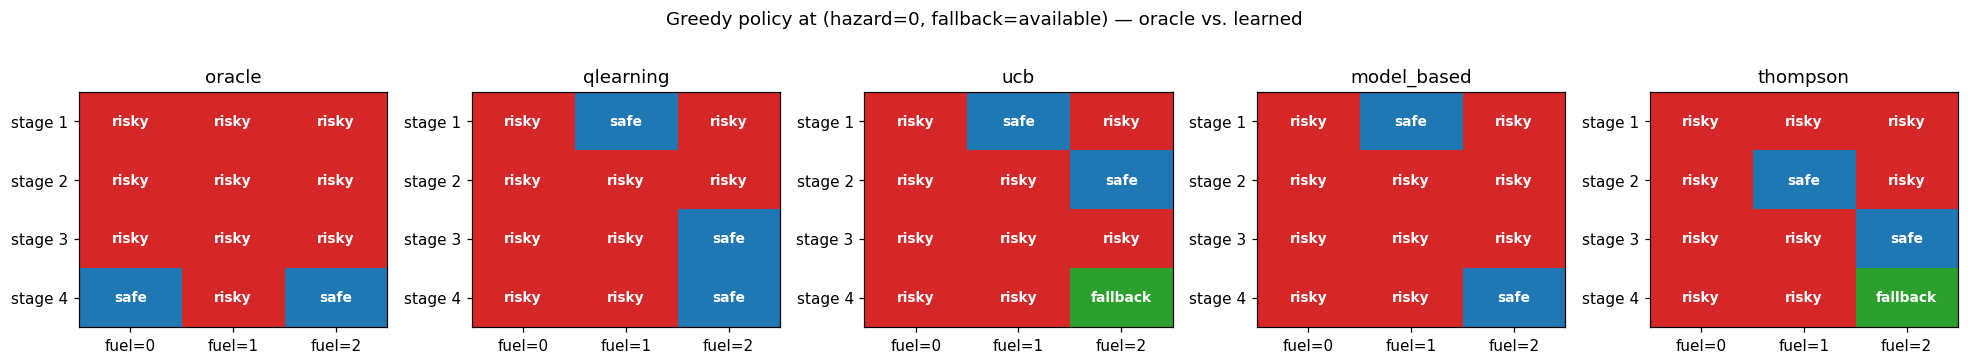

In [19]:
action_colors = ['#1f77b4', '#d62728', '#2ca02c', '#dddddd']  # safe, risky, fallback, -
action_nums = {'safe': 0, 'risky': 1, 'fallback': 2, '-': 3}

def policy_grid(pi):
    grid = np.empty((4, 3), dtype=object)
    for stage in range(1, 5):
        for fuel in (0, 1, 2):
            s = encode_state(stage, fuel, 0, 0)
            grid[stage - 1, fuel] = anames[int(pi[s])] if (action_mask_int(s) == 1).any() else '-'
    return grid

agent_policies = {}
for kind in AGENTS:
    Q = train_and_get_Q(kind, seed=0, n_ep=N_EP)
    agent_policies[kind] = greedy_pi_from_q(Q)

fig, axes = plt.subplots(1, 5, figsize=(18, 3.2))
cmap = plt.matplotlib.colors.ListedColormap(action_colors)
for ax, (title, pi) in zip(axes, [('oracle', pi_star)] + list(agent_policies.items())):
    grid = policy_grid(pi)
    num_grid = np.vectorize(action_nums.get)(grid)
    ax.imshow(num_grid, cmap=cmap, vmin=0, vmax=3, aspect='auto')
    for i in range(4):
        for j in range(3):
            ax.text(j, i, grid[i, j], ha='center', va='center', fontsize=9,
                    color='white', fontweight='bold')
    ax.set_title(title)
    ax.set_xticks([0, 1, 2]); ax.set_xticklabels(['fuel=0', 'fuel=1', 'fuel=2'])
    ax.set_yticks([0, 1, 2, 3]); ax.set_yticklabels([f'stage {i}' for i in range(1, 5)])
fig.suptitle('Greedy policy at (hazard=0, fallback=available) — oracle vs. learned', y=1.02)
plt.tight_layout(); plt.show()

## 7. Expected vs. observed results

**Context — task difficulty:** Section 2 measured the **oracle success rate at ≈ 0.48** (see verification cell). That is the *upper bound* any learner can reach on this MDP because even the optimal "risky-risky-risky-safe" policy only compounds to ≈ 0.48 due to the three stochastic risky stages. Success should therefore be compared *relative to 0.48*, not against an absolute 0.80 target.

The project proposal predicted:
- UCB-style and Thompson-style exploration should learn **safer and more fuel-efficient** policies than standard Q-learning.
- The model-based method should perform strongly once enough data has been collected.
- Under too-easy settings all methods may look similar; under too-harsh settings learning may become unstable.

The cell below compares each prediction against our actual numbers from the multi-seed sweep and the four environment variants, reporting both absolute success and **% of oracle** reached.

- **Model-based VI** and **PSRL/Thompson** should converge fastest because they replan using a learned/sampled MDP.
- **UCB-Q** typically beats epsilon-greedy **Q-learning** on cumulative regret because its exploration adapts to visit counts.
- Under **harsh_hazard** the oracle and learners shift toward safer routes; the hazard rate drops.
- Under **weak_fallback** the fallback is less valuable, so risky failures more often turn into terminal failures.
- Under **low_fuel** hazard and fallback branches become fragile: any fuel-consuming miss can end the mission.

In [20]:
def _mean_by_agent(frame, col):
    return frame.groupby('agent')[col].mean().to_dict()

base_succ = _mean_by_agent(df, 'final_success')
base_ret  = _mean_by_agent(df, 'final_return')
base_haz  = _mean_by_agent(df, 'hazard_rate')
base_reg  = _mean_by_agent(df, 'total_regret')

print(f'Oracle success (from §2 Monte-Carlo) = {oracle_succ:.3f}   <- upper bound for any learner')
print('==== Default mission (5 seeds) ====')
print(f"{'agent':<12} {'success':>8} {'%oracle':>8} {'return':>8} {'hazard':>8} {'regret':>10}")
for a in AGENTS:
    pct = 100.0 * base_succ[a] / max(oracle_succ, 1e-9)
    print(f'{a:<12} {base_succ[a]:>8.3f} {pct:>7.0f}% {base_ret[a]:>8.2f} {base_haz[a]:>8.3f} {base_reg[a]:>10.1f}')

ql_succ = base_succ['qlearning']
ucb_ts_best_succ = max(base_succ['ucb'], base_succ['thompson'])
ql_reg = base_reg['qlearning']
ucb_ts_best_reg = min(base_reg['ucb'], base_reg['thompson'])
mb_succ = base_succ['model_based']
best_succ_agent = max(base_succ, key=base_succ.get)
best_succ_val = base_succ[best_succ_agent]

print('\n==== Claim checks ====')
print('Claim: UCB/Thompson beat Q-learning on success rate.')
print(f'  Q-learning = {ql_succ:.3f}; best(UCB, Thompson) = {ucb_ts_best_succ:.3f}  '
      f"=> {'CONFIRMED' if ucb_ts_best_succ > ql_succ + 0.005 else 'NOT CONFIRMED'}")
print('Claim: UCB/Thompson have lower cumulative regret than Q-learning.')
print(f'  Q-learning regret = {ql_reg:.1f}; best(UCB, Thompson) = {ucb_ts_best_reg:.1f}  '
      f"=> {'CONFIRMED' if ucb_ts_best_reg < ql_reg - 0.5 else 'NOT CONFIRMED'}")
print('Claim: Model-based VI performs strongly once enough data is collected.')
print(f'  Model-based success = {mb_succ:.3f} (best overall = {best_succ_val:.3f} by {best_succ_agent})  '
      f"=> {'CONFIRMED' if mb_succ >= best_succ_val - 0.02 else 'WEAKER THAN EXPECTED'}")

print('\n==== Robustness across environment variants ====')
robust = vdf.groupby('agent')['final_success'].mean().to_dict()
for a, v in sorted(robust.items(), key=lambda x: -x[1]):
    print(f'  {a:<12} mean success across variants = {v:.3f}')
best_robust = max(robust, key=robust.get)
print(f'=> Most robust across variants: {best_robust} ({robust[best_robust]:.3f})')

Oracle success (from §2 Monte-Carlo) = 0.478   <- upper bound for any learner
==== Default mission (5 seeds) ====
agent         success  %oracle   return   hazard     regret
qlearning       0.318      66%   -27.74    0.122    63060.4
ucb             0.344      72%   -22.94    0.127    48853.4
model_based     0.326      68%   -27.08    0.127    58935.4
thompson        0.284      59%   -32.24    0.106    71485.4

==== Claim checks ====
Claim: UCB/Thompson beat Q-learning on success rate.
  Q-learning = 0.318; best(UCB, Thompson) = 0.344  => CONFIRMED
Claim: UCB/Thompson have lower cumulative regret than Q-learning.
  Q-learning regret = 63060.4; best(UCB, Thompson) = 48853.4  => CONFIRMED
Claim: Model-based VI performs strongly once enough data is collected.
  Model-based success = 0.326 (best overall = 0.344 by ucb)  => CONFIRMED

==== Robustness across environment variants ====
  ucb          mean success across variants = 0.272
  qlearning    mean success across variants = 0.265
  mod